# Normalization and pre-tokenization

Before we dive more deeply into the three most common subword tokenization algorithms used with Transformer models (Byte-Pair Encoding [BPE], WordPiece, and Unigram), we’ll first take a look at the preprocessing that each tokenizer applies to text. Here’s a high-level overview of the steps in the tokenization pipeline:



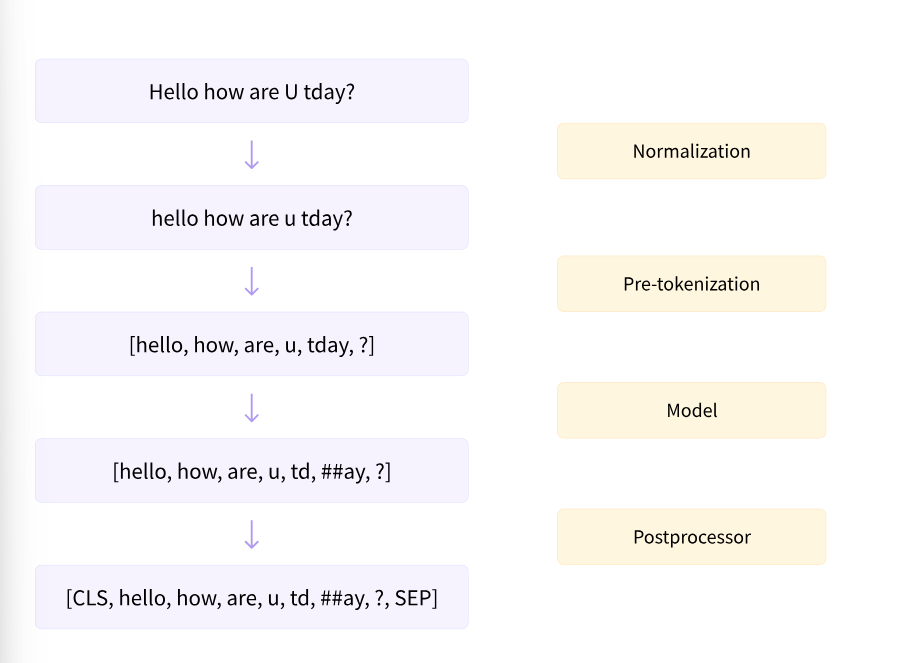

# 1.Normalization

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\rag-multimodal-iRO9Larq-py3.12\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The Transformers tokenizer has an attribute called backend_tokenizer that provides access to the underlying tokenizer from the Tokenizers library

In [2]:
type(tokenizer.backend_tokenizer)

tokenizers.Tokenizer

The normalizer attribute of the tokenizer object has a normalize_str() method that we can use to see how the normalization is performed:

In [6]:
print(tokenizer.backend_tokenizer.normalizer.normalize_str("Héllò hôw are ü?"))

hello how are u?


# 2.Pre-tokenization

To see how a fast tokenizer performs pre-tokenization, we can use the pre_tokenize_str() method of the pre_tokenizer attribute of the tokenizer object:

In [7]:
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('how', (7, 10)),
 ('are', (11, 14)),
 ('you', (16, 19)),
 ('?', (19, 20))]

Notice how the tokenizer is already keeping track of the offsets, which is how it can give us the offset mapping we used in the previous section. Here the tokenizer ignores the two spaces and replaces them with just one, but the offset jumps between are and you to account for that.

Since we’re using a BERT tokenizer, the pre-tokenization involves splitting on whitespace and punctuation. Other tokenizers can have different rules for this step. For example, if we use the GPT-2 tokenizer:

In [8]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('Ġhow', (6, 10)),
 ('Ġare', (10, 14)),
 ('Ġ', (14, 15)),
 ('Ġyou', (15, 19)),
 ('?', (19, 20))]

it will split on whitespace and punctuation as well, but it will keep the spaces and replace them with a Ġ symbol, enabling it to recover the original spaces if we decode the tokens:

For a last example, let’s have a look at the T5 tokenizer, which is based on the SentencePiece algorithm:

In [10]:
tokenizer = AutoTokenizer.from_pretrained("t5-small")
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('▁Hello,', (0, 6)),
 ('▁how', (7, 10)),
 ('▁are', (11, 14)),
 ('▁you?', (16, 20))]

Like the GPT-2 tokenizer, this one keeps spaces and replaces them with a specific token (_), but the T5 tokenizer only splits on whitespace, not punctuation. Also note that it added a space by default at the beginning of the sentence (before Hello) and ignored the double space between are and you.